**Cataract Classification EFFICIENTNET B0**

In [ ]:

# ==============================
# 1. MOUNT GOOGLE DRIVE
# ==============================
from google.colab import drive
drive.mount('/content/drive')

# ==============================
# 2. IMPORT LIBRARY
# ==============================
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

# ==============================
# 3. GPU + OPTIMASI
# ==============================
print("GPU Available:", tf.config.list_physical_devices('GPU'))

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# ==============================
# 4. PATH DATASET
# ==============================
TRAIN_DIR = '/content/drive/MyDrive/Dataset/Dataset/train'
VAL_DIR   = '/content/drive/MyDrive/Dataset/Dataset/valid'
TEST_DIR  = '/content/drive/MyDrive/Dataset/Dataset/test'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50

# ==============================
# 5. CEK DATASET
# ==============================
print("Train folders:", os.listdir(TRAIN_DIR))
print("Valid folders:", os.listdir(VAL_DIR))
if os.path.exists(TEST_DIR):
    print("Test folders :", os.listdir(TEST_DIR))

# ==============================
# 6. LOAD DATASET
# ==============================
print("\n--- Loading Datasets ---")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)
class_names = train_dataset.class_names

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Test dataset dimuat secara terpisah untuk menjaga objektivitas (bebas dari data leakage)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"\nClasses: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)


# ==============================
# 7. BUILD MODEL (IMPROVED)
# ==============================
def build_model():

    # Augmentasi
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.1),
        tf.keras.layers.RandomTranslation(0.02, 0.02),
        tf.keras.layers.RandomContrast(0.1),
        tf.keras.layers.RandomBrightness(0.05),
    ])

    preprocess_input = tf.keras.applications.efficientnet.preprocess_input

    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=(224,224,3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    inputs = tf.keras.Input(shape=(224,224,3))

    # Augmentasi + preprocessing + Feature extraction
    x = data_augmentation(inputs)
    x = preprocess_input(x)
    x = base_model(x, training=False)

    # =========================
    # OPTIMASI FITUR
    # =========================

    # Multi pooling
    avg_pool = tf.keras.layers.GlobalAveragePooling2D()(x)
    max_pool = tf.keras.layers.GlobalMaxPooling2D()(x)
    x = tf.keras.layers.Concatenate()([avg_pool, max_pool])

    # Normalisasi
    x = tf.keras.layers.BatchNormalization()(x)

    # Dense layer (pakai swish sesuai EfficientNet)
    x = tf.keras.layers.Dense(512, activation='swish')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    x = tf.keras.layers.Dense(128, activation='swish')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.Dense(32, activation='swish')(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    # Output
    outputs = tf.keras.layers.Dense(1000, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)
    return model

model = build_model()
model.summary()

# ==============================
# 8. COMPILE
# ==============================
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==============================
# 9. CALLBACK
# ==============================
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/best_efficientnetb0.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

# ==============================
# 10. TRAINING
# ==============================
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=callbacks
)

# ==============================
# 11. GRAFIK
# ==============================
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
plt.title("Grafik Akurasi Training & Validation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
plt.title("Grafik Loss Training & Validation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# ==============================
# 12. EVALUASI
# ==============================
y_pred = []
y_true = []

for images, labels in val_dataset:
    preds = model.predict(images)
    y_pred.extend((preds > 0.4).astype(int).flatten())
    y_true.extend(labels.numpy())

print("\n=== CLASSIFICATION REPORT ===\n")
print(classification_report(y_true, y_pred, target_names=class_names))
# ==============================
# 13. CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - EfficientNetB0 Test Set")
plt.show()

Mounted at /content/drive
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Train folders: ['Normal', 'cataract']
Valid folders: ['Normal', 'cataract']
Test folders : ['cataract', 'Normal']

--- Loading Datasets ---
Found 4550 files belonging to 2 classes.
Found 975 files belonging to 2 classes.
Found 975 files belonging to 2 classes.

Classes: ['Normal', 'cataract']


NameError: name 'base_model' is not defined

1. MOUNT GOOGLE DRIVE

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. IMPORT LIBRARY

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

3.  GPU + OPTIMASI

In [3]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


4. PATH DATASET

In [4]:
TRAIN_DIR = '/content/drive/MyDrive/Dataset/Dataset/train'
VAL_DIR   = '/content/drive/MyDrive/Dataset/Dataset/valid'
TEST_DIR  = '/content/drive/MyDrive/Dataset/Dataset/test'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50

5. CEK DATASET

In [5]:
print("Train folders:", os.listdir(TRAIN_DIR))
print("Valid folders:", os.listdir(VAL_DIR))
if os.path.exists(TEST_DIR):
    print("Test folders :", os.listdir(TEST_DIR))

Train folders: ['Normal', 'cataract']
Valid folders: ['Normal', 'cataract']
Test folders : ['cataract', 'Normal']


6. LOAD DATASET

In [6]:
print("\n--- Loading Datasets ---")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)
class_names = train_dataset.class_names

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"\nClasses: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)


--- Loading Datasets ---
Found 4550 files belonging to 2 classes.
Found 975 files belonging to 2 classes.
Found 975 files belonging to 2 classes.

Classes: ['Normal', 'cataract']


7. BUILD MODEL (IMPROVED)

In [7]:
def build_model(num_classes):
    inputs = tf.keras.Input(shape=(224, 224, 3), name="Input_Image")

    # Data Augmentation
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.1),
    ], name="Augmentation")

    preprocess_input = tf.keras.applications.efficientnet.preprocess_input
    x = data_augmentation(inputs)
    x = preprocess_input(x)

    # Backbone: EfficientNet-B0 (4.049.571 params)
    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    x = base_model(x, training=False)

    # Global Average Pooling
    x = tf.keras.layers.GlobalAveragePooling2D(name="Global_Average_Pooling")(x)
    x = tf.keras.layers.Dropout(rate=0.2, name="Dropout")(x)

    # Output Layer 1000 Node (1.281.000 params)
    # Total Params = 4.049.571 + 1.281.000 = 5.330.571 (~5,33 Juta)
    outputs = tf.keras.layers.Dense(1000, activation="softmax", dtype='float32', name="Dense_1000")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="EfficientNetB0_Standard")
    return model

model = build_model(num_classes=1000)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "EfficientNetB0_Standard"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Global_Average_Pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1000 (Dense)              │ (None, 1000)           │     1,281,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,330,571 (20.33 MB)

 Trainable params: 1,281,000 (4.89 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

8. COMPILE

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

9. CALLBACK

In [9]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/best_efficientnetb0.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

10. TRAINING

In [ ]:
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=callbacks
)

Epoch 1/50
142/143 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6270 - loss: 0.7145
Epoch 1: val_accuracy improved from None to 0.82974, saving model to /content/drive/MyDrive/best_efficientnetb0.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_efficientnetb0.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 30s 117ms/step - accuracy: 0.6971 - loss: 0.6070 - val_accuracy: 0.8297 - val_loss: 0.3827 - learning_rate: 1.0000e-04
Epoch 2/50
142/143 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7852 - loss: 0.4611
Epoch 2: val_accuracy improved from 0.82974 to 0.86667, saving model to /content/drive/MyDrive/best_efficientnetb0.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_efficientnetb0.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - accuracy: 0.7912 - loss: 0.4447 - val_accuracy: 0.8667 - val_loss: 0.2904 - learning_rate: 1.0000e-04
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8326 - loss: 0.4030
Epoch 3: val_accuracy improved from 0

11. Grafik

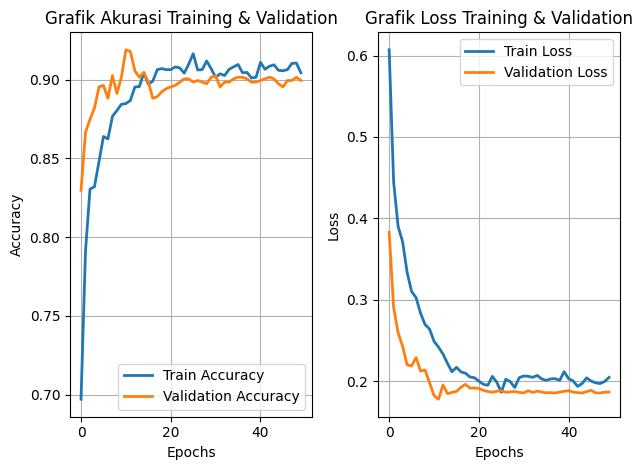

In [ ]:
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
plt.title("Grafik Akurasi Training & Validation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
plt.title("Grafik Loss Training & Validation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

12. Evaluasi

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

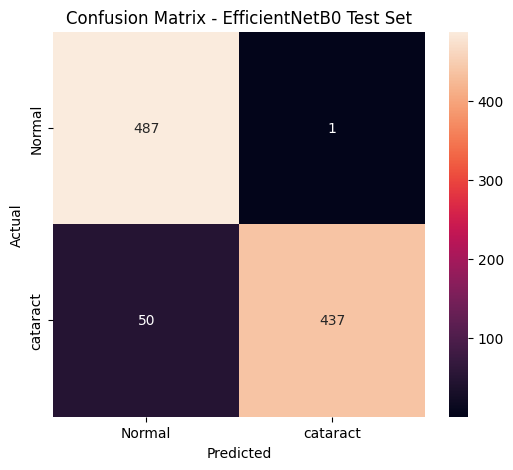

In [ ]:
y_pred = []
y_true = []

for images, labels in val_dataset:
    preds = model.predict(images)
    y_pred.extend((preds > 0.4).astype(int).flatten())
    y_true.extend(labels.numpy())

print("\n=== CLASSIFICATION REPORT ===\n")
print(classification_report(y_true, y_pred, target_names=class_names))
# ==============================
# 13. CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - EfficientNetB0 Test Set")
plt.show()